# A Two-Tank Cascade with an Unknown Discharge Law

This vignette walks through a complete `SiNDAE` workflow on a small index-1 DAE:
define the problem, fit a hybrid model, predict an unseen operating condition,
and plot both. Larger systems (including an index-2 DAE and a multi-trajectory
decomposition fit) are in the
[examples gallery](https://alves-research-group.github.io/SiNDAE/index-2/).

Two tanks drain in cascade. Tank 1 receives a constant feed $F_{in}$ and
discharges into tank 2 through a valve; tank 2 discharges to the environment.
The liquid levels $h_1(t), h_2(t)$ are differential states and the flows
$q_1(t), q_2(t)$ are algebraic variables:

$$
\begin{align}
A_1 \frac{dh_1}{dt} &= F_{in} - q_1 \tag{1}\\
A_2 \frac{dh_2}{dt} &= q_1 - q_2 \tag{2}\\
q_2 &= c_2 \sqrt{h_2} \tag{3}
\end{align}
$$

Equation (3) is a known algebraic relation and `SiNDAE` enforces it as a hard
constraint at every collocation point, during training and during prediction.
The discharge law of tank 1 is the *unknown* term. Instead of postulating a
form for it we learn it as a function of the measured levels:

$$
\begin{align}
q_1(t) = z(t) = f_{NN}\big(h_1, h_2;\ \theta\big) \tag{4}
\end{align}
$$

The true law happens to be $q_1 = c_1 \sqrt{h_1}$. We never give that to the
solver; it is kept only to generate synthetic measurements and to check the
recovered relation at the end.

Start with the imports.

In [1]:
%matplotlib inline

import logging

import jax
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae import HybridDAE, generate_data
from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.solvers import SolverConfig
from sindae.plot_utils import plot_instance_data

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
for _noisy in ('pyomo', 'jax2onnx', 'onnx_ir'):
    logging.getLogger(_noisy).setLevel(logging.ERROR)

## Step 1 - Define the problem

A system is a `ProblemDefinition` subclass with three required methods.
`build_trajectory()` writes the DAE for one trajectory in Pyomo,
`get_input_vars()` returns the variables fed into the network, and
`get_output_vars()` returns the variables it produces. The optional
`get_aux_vars()` tracks the algebraic flows and `add_true_output_constraints()`
supplies the reference law used only for synthetic data generation.

In [2]:
class TwoTankProblem(ProblemDefinition):

    def __init__(self, params, ics, t_span, nfe, ncp,
                 obs_times=None, obs_values=None):
        super().__init__(ics, input_dim=2, z_dim=1, t_span=t_span,
                         nfe=nfe, ncp=ncp, obs_dim=2, aux_vars_dim=2,
                         obs_times=obs_times, obs_values=obs_values)
        self.params = params

    def build_trajectory(self, block, traj_idx):
        t0, p, h0 = self.t_span[0], self.params, self.ics[traj_idx]

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.h    = pyo.Var(block.t, range(2), bounds=(1e-3, None), initialize=1.0)
        block.q    = pyo.Var(block.t, range(2), bounds=(0.0, None), initialize=0.5)
        block.z    = pyo.Var(block.t, range(1), initialize=0.5)
        block.dhdt = dae.DerivativeVar(block.h, wrt=block.t)

        @block.Constraint(block.t, range(2))          # Eqns (1) and (2)
        def diffeq(b, t, s):
            if s == 0:
                return p['A1'] * b.dhdt[t, 0] == p['Fin'] - b.q[t, 0]
            return p['A2'] * b.dhdt[t, 1] == b.q[t, 0] - b.q[t, 1]

        @block.Constraint(block.t)                    # Eqn (3), known, hard
        def outlet_valve(b, t):
            return b.q[t, 1] == p['c2'] * pyo.sqrt(b.h[t, 1])

        @block.Constraint(block.t)                    # Eqn (4), learned
        def inlet_valve(b, t):
            return b.q[t, 0] == b.z[t, 0]

        for j in range(2):                            # initial levels
            block.h[t0, j].fix(float(h0[j]))

    def get_input_vars(self, block, t):
        return [block.h[t, j] for j in range(2)]

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

    def get_aux_vars(self, block, t):
        return [block.q[t, j] for j in range(2)]

    def add_true_output_constraints(self, block):
        @block.Constraint(block.t)                    # reference law, data only
        def true_z(b, t):
            return b.z[t, 0] == self.params['c1'] * pyo.sqrt(b.h[t, 0])

## Step 2 - Instantiate and generate measurements

Three batches start from different levels, giving the network a range of
$h_1$ to learn over. `generate_data()` solves the reference model on the
collocation grid, samples every fourth point, and adds Gaussian noise. It
attaches the result to the problem as `obs_times` / `obs_values`, which is
exactly where your own measurements would go.

In [3]:
PARAMS = {
    'A1':  1.0,    # tank 1 cross-section
    'A2':  1.5,    # tank 2 cross-section
    'Fin': 0.5,    # constant feed to tank 1
    'c2':  0.4,    # tank 2 valve coefficient (known)
    'c1':  0.5,    # tank 1 valve coefficient (reference only)
}

ICS = np.array([
    [3.0, 0.5],    # traj 0: [h_1, h_2] at t = 0
    [0.5, 2.5],    # traj 1
    [2.0, 1.0],    # traj 2
])

T_SPAN = (0.0, 40.0)
SEED = 0

problem = TwoTankProblem(params=PARAMS, ics=ICS, t_span=T_SPAN, nfe=40, ncp=3)

true_data = generate_data(problem, noise_std=np.array([0.03, 0.03]),
                          obs_every=4, seed=SEED)

generate_data: ok / optimal


## Step 3 - Define the network and fit

The network maps the two levels to the unknown discharge. `HybridDAE` takes the
prebuilt network plus one config object per pipeline stage, then `fit()` runs
the whole pipeline: a smoother solve that recovers smooth state and $z$
trajectories from the noisy data, supervised pretraining of the network on
those pairs, and the simultaneous solve that trains the weights and the
discretized DAE at once. Passing `metrics=` prints the fit quality per state
and trajectory.

Once fitted, `export()` hands the trained network off to other tooling.
`scaled=True` bakes the normalization statistics into the exported ONNX graph,
so the written file maps raw physical levels to a raw physical discharge with
no sidecar arithmetic. JSON export and an in-memory OMLT `NetworkDefinition`
(via `to_omlt()`) are the other two targets.

In [4]:
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[16, 16],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)

model = HybridDAE(
    method='simultaneous',
    nlp_solver='pounce',
    linear_solver='feral',
    net=mlp,
    smoother=SmootherConfig(smooth_coef=1.0),
    pretrain=PretrainConfig(epochs=200, batch_size=32, reg_coef=1e-3),
    train=SimultaneousConfig(use_gbm=False, reg_coef=1e-3),
    solver_options=SolverConfig(tol=1e-6, max_iter=1000),
)

model.fit(problem, metrics=['rmse'])

print('termination:', model.termination)
print('exported to:', model.export('two_tank_net.onnx', scaled=True))

=== Building smoother for 3 trajectories (smooth_coef=1.0) ===


  Smoother: ok / optimal


=== Building simultaneous (expr-writing) model for 3 trajectories ===


=== Solving simultaneous model (pounce, expr-writing) ===


  pounce: ok / optimal


=== Simultaneous solve complete ===


=== Per Trajectory Metrics ===
RMSE: 
╒════════╤═══════════╤═══════════╤═══════════╕
│        │       x_0 │       x_1 │     NRMSE │
╞════════╪═══════════╪═══════════╪═══════════╡
│ traj_0 │ 0.0275517 │ 0.0259707 │ 0.0162314 │
├────────┼───────────┼───────────┼───────────┤
│ traj_1 │ 0.0248695 │ 0.0321847 │ 0.0421323 │
├────────┼───────────┼───────────┼───────────┤
│ traj_2 │ 0.0315749 │ 0.0242519 │ 0.0314872 │
├────────┼───────────┼───────────┼───────────┤
│ mean   │ 0.0279987 │ 0.0274691 │ 0.0299503 │
╘════════╧═══════════╧═══════════╧═══════════╛
termination: optimal


Converting JAX function to ONNX model with parameters: model_name=jax_model, opset=23, input_shapes=[('B', 2)], input_params=None, enable_double_precision=True, record_primitive_calls_file=None, return_mode=file, output_path=two_tank_net.onnx, inputs_as_nchw=None, outputs_as_nchw=None, input_names=None, output_names=None, export_mode=standard


exported to: two_tank_net.onnx


## Step 4 - Plot the fit

Every intermediate stays reachable on the fitted object, so the smoother
initialization and the trained trajectories can be plotted against the
measurements. `plot_instance_data()` lays trajectories out as rows and
variables as columns.

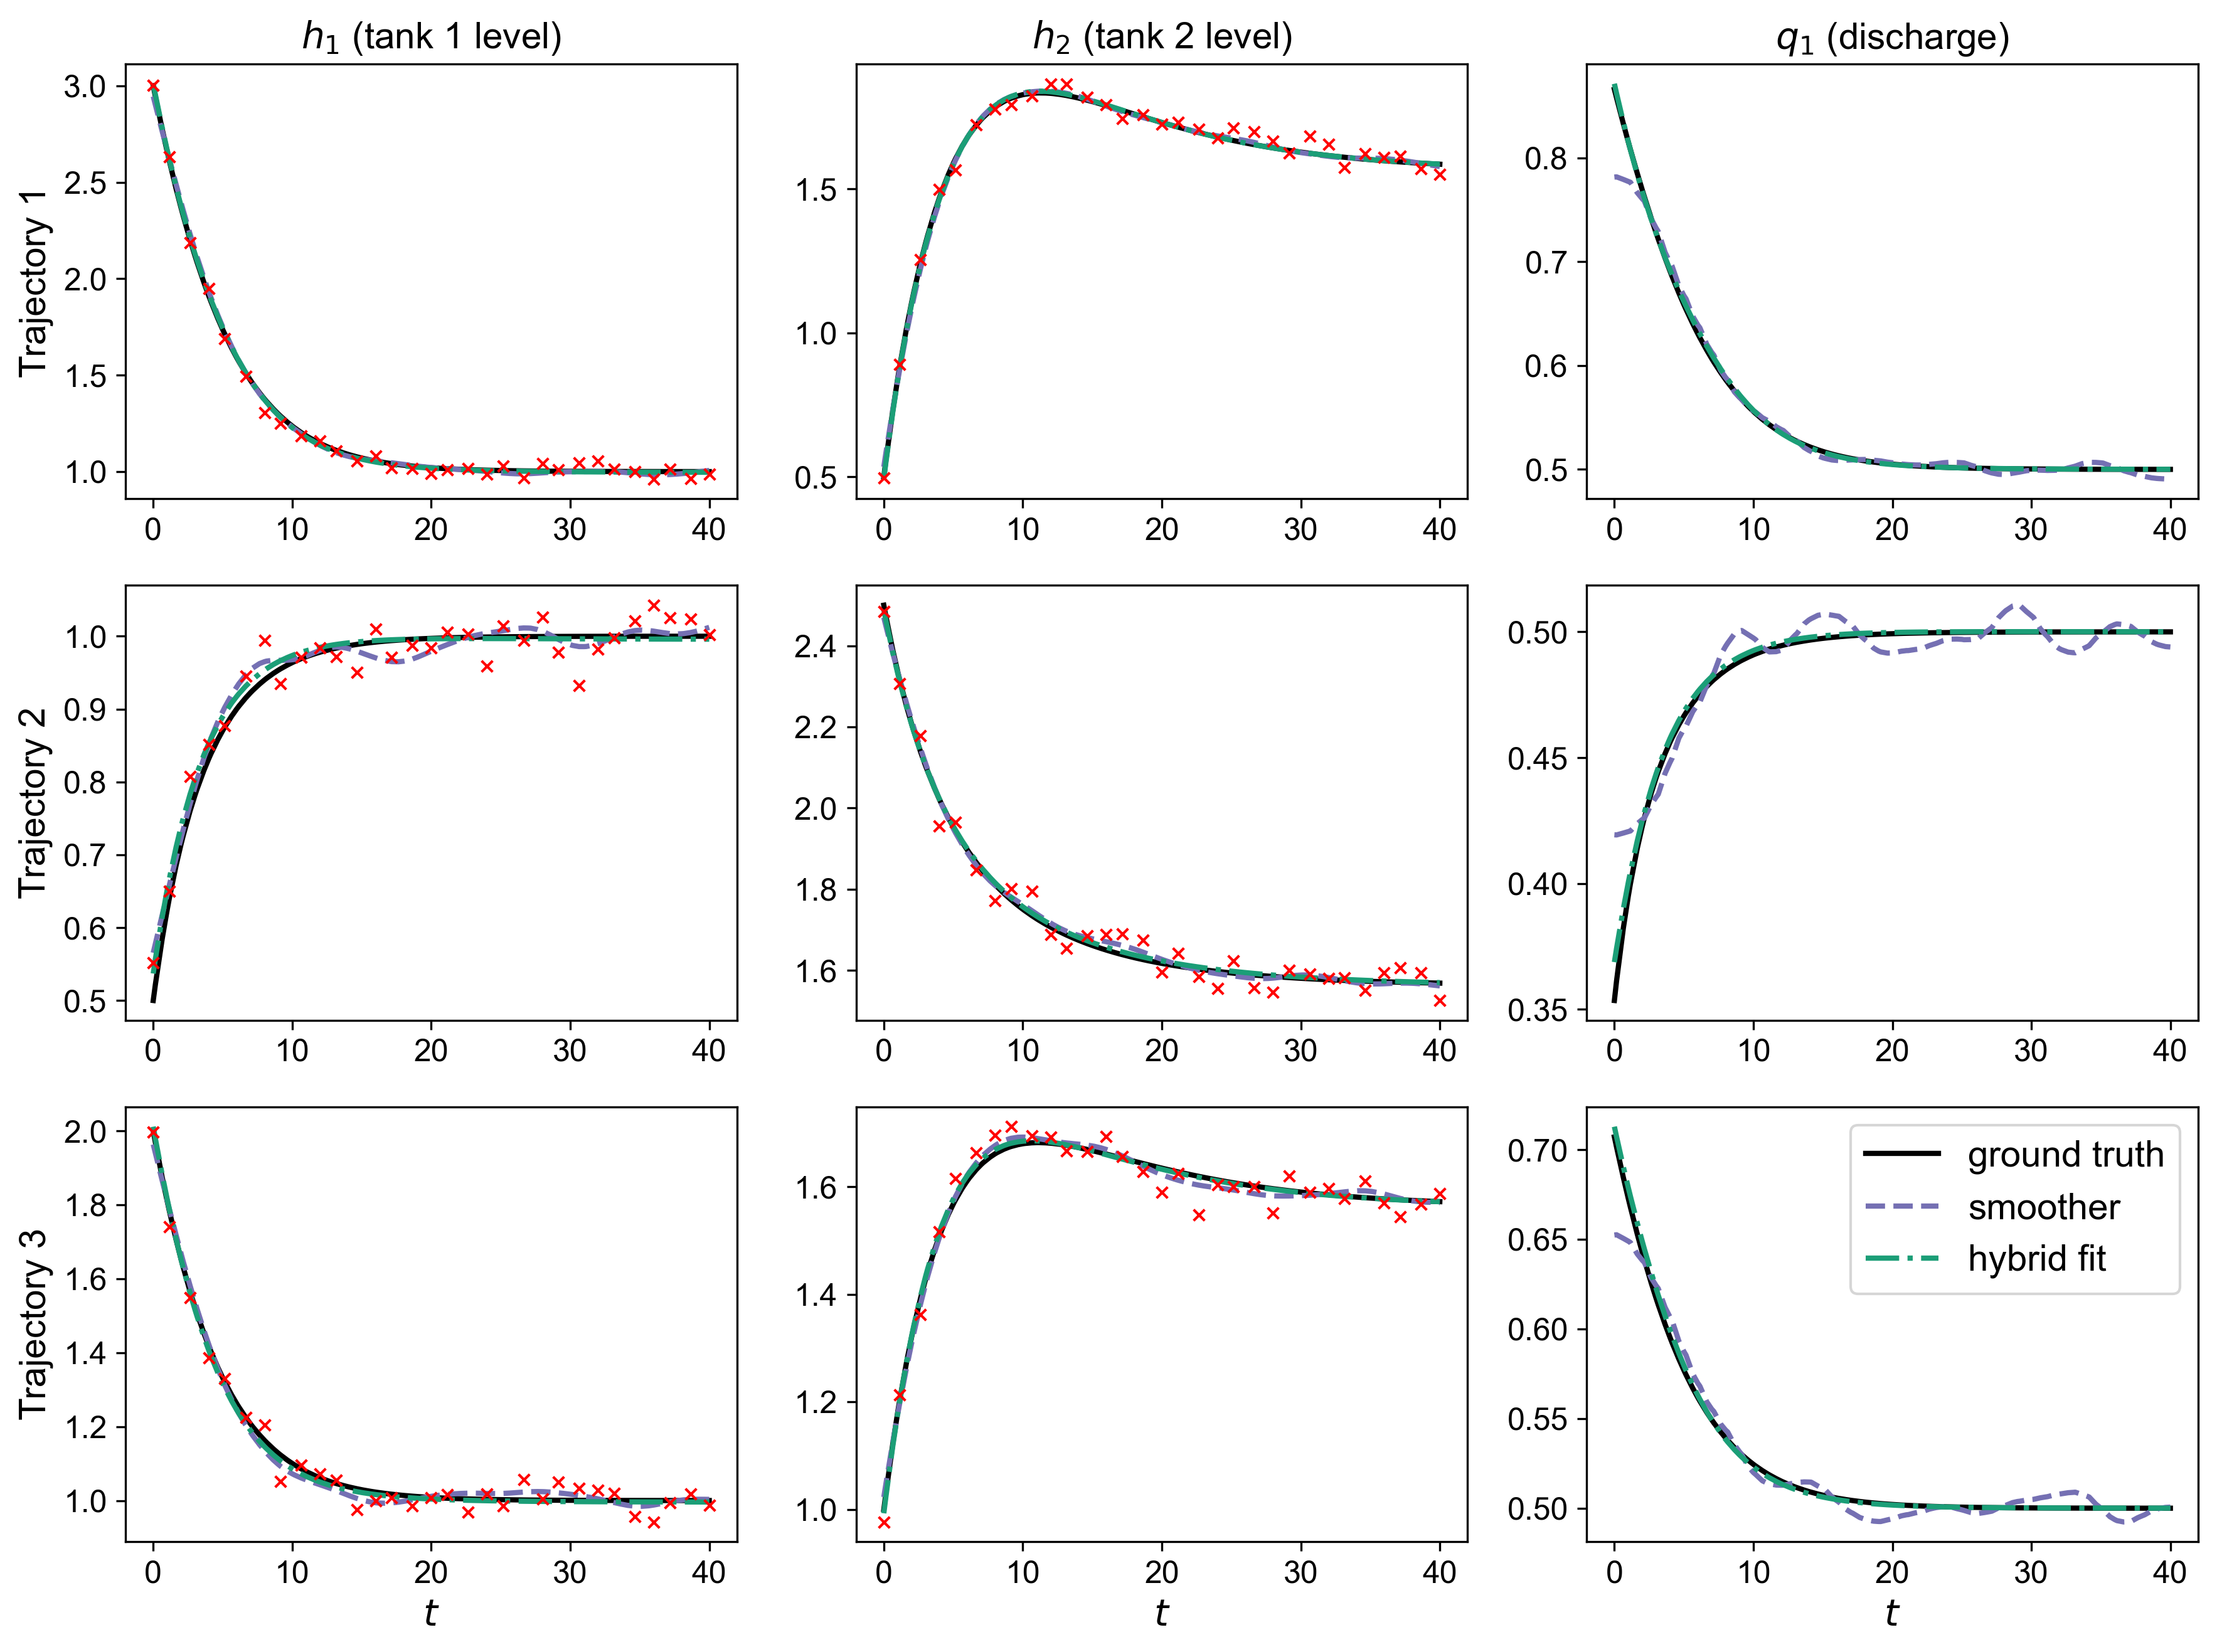

In [5]:
STATE_NAMES = ['$h_1$ (tank 1 level)', '$h_2$ (tank 2 level)']
OUTPUT_NAME = ['$q_1$ (discharge)']

datasets = [
    (true_data,            'ground truth', {'color': 'black', 'ls': '-'}),
    (model.smoother_data,  'smoother',     {'color': 'C2',    'ls': '--'}),
    (model.trained_data,   'hybrid fit',   {'color': 'C0',    'ls': '-.'}),
]

fig_fit, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAME,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs', 'outputs'],
    legend_placement='last',
)
fig_fit.savefig('images/vignette_fit.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5 - Inspect the recovered law

The network was never told that $q_1$ depends on $h_1$ alone, yet plotting the
trained output against $h_1$ collapses the three trajectories onto a single
curve that tracks $c_1 \sqrt{h_1}$.

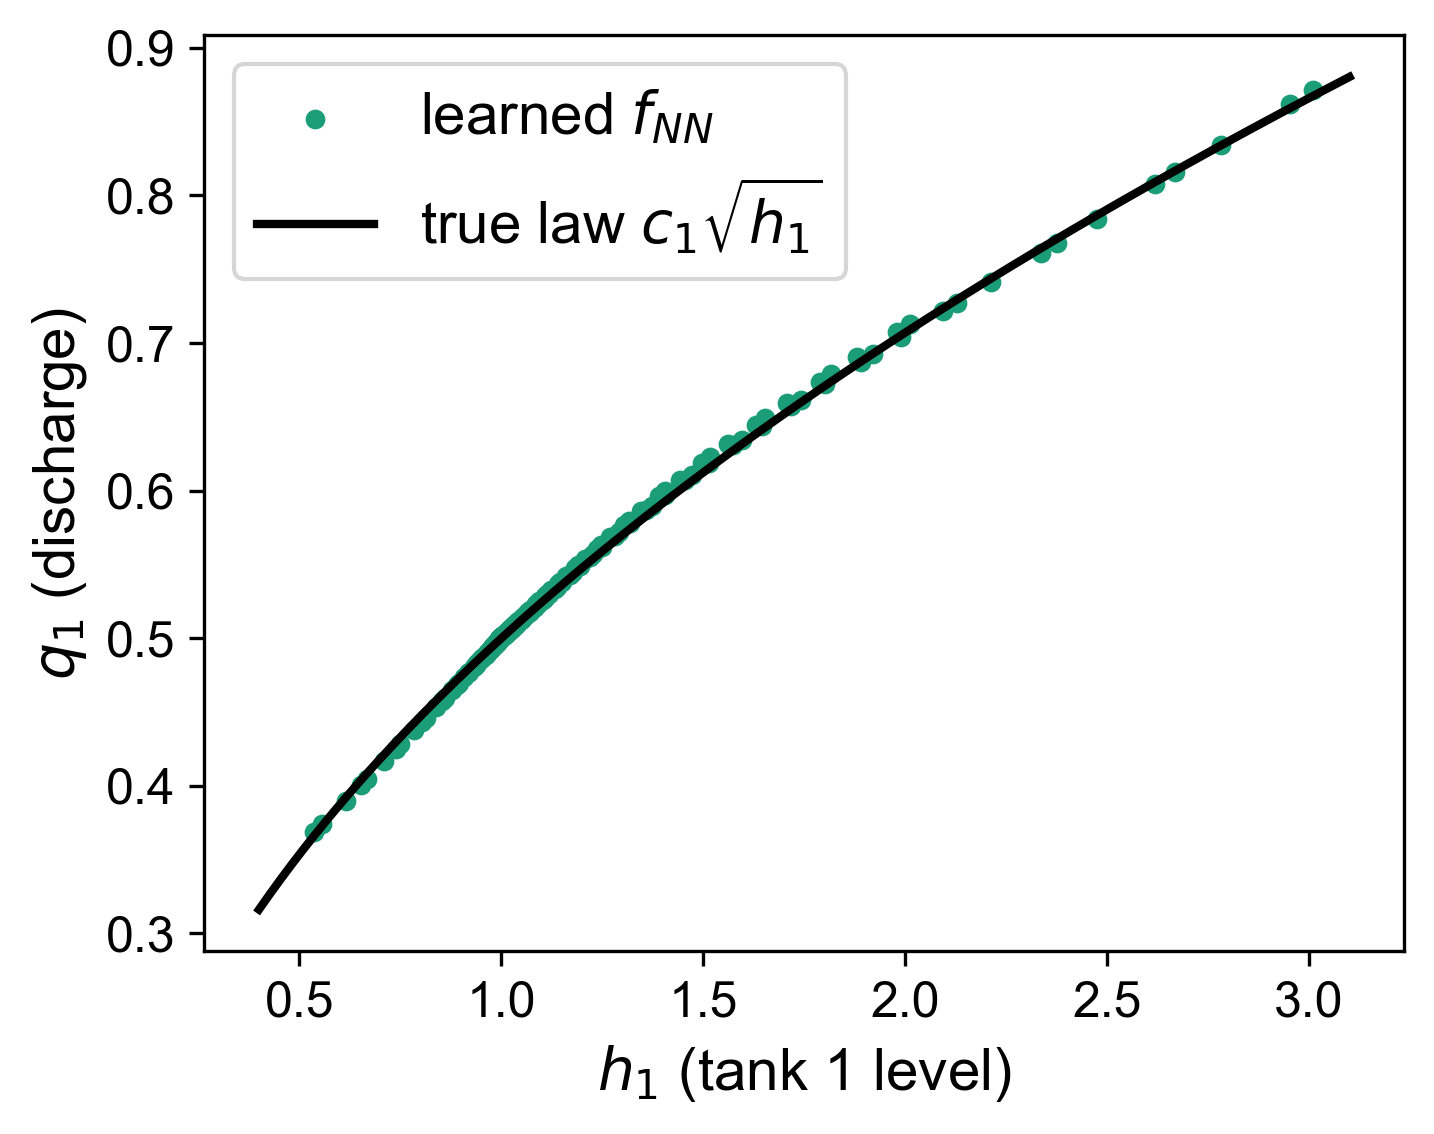

In [6]:
fig_law, ax = plt.subplots(figsize=(5, 4))

for b in range(problem.num_trajectories):
    ax.scatter(model.trained_data[b].nn_input[:, 0],
               model.trained_data[b].nn_output[:, 0],
               s=14, color='C0', label='learned $f_{NN}$' if b == 0 else None)

h_grid = np.linspace(0.4, 3.1, 200)
ax.plot(h_grid, PARAMS['c1'] * np.sqrt(h_grid), 'k-',
        label=r'true law $c_1\sqrt{h_1}$')

ax.set_xlabel('$h_1$ (tank 1 level)')
ax.set_ylabel('$q_1$ (discharge)')
ax.legend()
fig_law.tight_layout()
fig_law.savefig('images/vignette_law.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6 - Predict an unseen start-up

`predict()` embeds the trained network in a new problem and solves the
inference NLP. The new problem is the same system with different initial
levels and a coarser grid, showing that the discretization used for prediction
need not match the one used for training. Because equations (1) to (3) are
enforced as hard constraints, the prediction is a feasible solution of the
mechanistic model rather than a free-running rollout.

In [7]:
val_problem = TwoTankProblem(params=PARAMS, ics=np.array([[2.5, 2.2]]),
                             t_span=T_SPAN, nfe=25, ncp=3)

val_truth = generate_data(val_problem, noise_std=np.zeros(2), obs_every=1, seed=SEED)
val_pred = model.predict(val_problem)

generate_data: ok / optimal


=== Building inference model for 1 trajectories (hard constraint) ===


=== Solving inference model ===


  Inference: ok / optimal


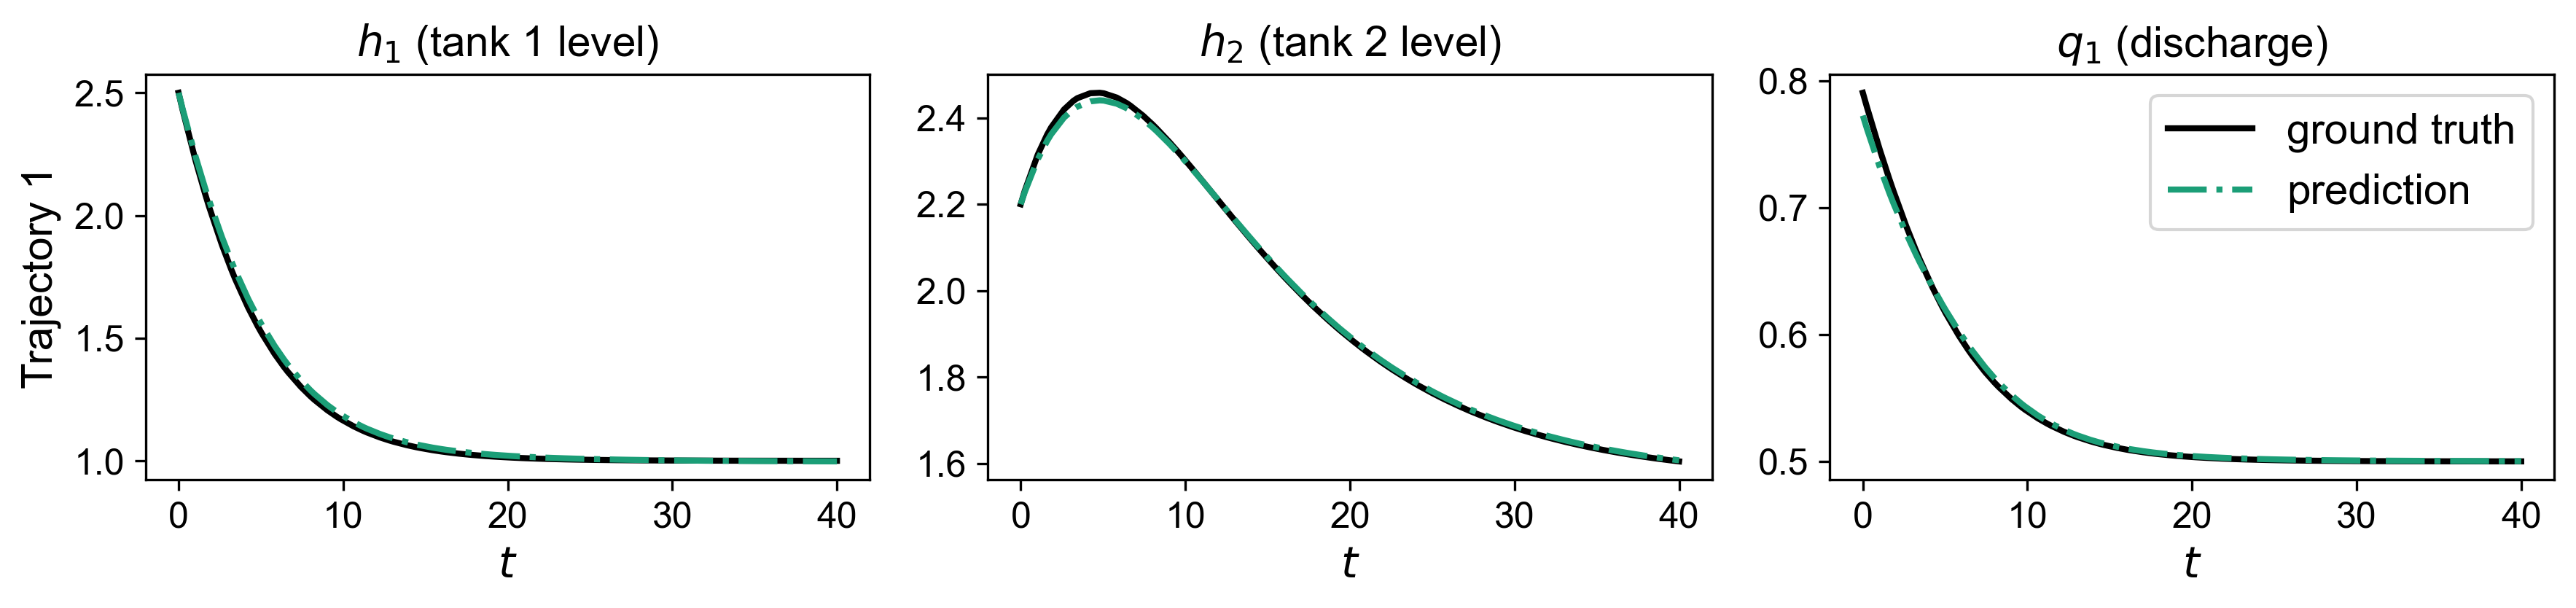

In [8]:
val_datasets = [
    (val_truth, 'ground truth', {'color': 'black', 'ls': '-'}),
    (val_pred,  'prediction',   {'color': 'C0',    'ls': '-.'}),
]

fig_pred, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAME,
    groups=['inputs', 'outputs'], legend_placement='last',
)
fig_pred.savefig('images/vignette_predict.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

Defining the DAE, fitting, and predicting took one `ProblemDefinition`
subclass and two calls, `fit()` and `predict()`, with the default
pip-installable solver stack (POUNCE and FERAL) and no external binaries. The
known algebraic relation held exactly throughout, and the unknown discharge law
was recovered from noisy level measurements alone.

{cite}`lueg2025simultaneous`